In [95]:
import pandas as pd

df = pd.read_csv("data/reduced_world_real_estate_data.csv")

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 7 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Country                       144961 non-null  object 
 1   Property Type                 144961 non-null  object 
 2   Size Factor                   144961 non-null  float64
 3   Price Factor                  144961 non-null  float64
 4   Bathroom Factor               144961 non-null  float64
 5   Building Age Factor           144961 non-null  float64
 6   Density vs. Modernity Factor  144961 non-null  float64
dtypes: float64(5), object(2)
memory usage: 7.7+ MB


In [97]:
pc_columns = [
    'Size Factor', 
    'Price Factor',
    'Bathroom Factor',
    'Building Age Factor',
    'Density vs. Modernity Factor'
]

country_comparison_df = df.groupby('Country')[pc_columns].mean()

country_comparison_df = country_comparison_df.sort_values(by='Size Factor', ascending=False)

print("\n--- Country comparison table (Top 10 countries by Size Factor) ---")
print(country_comparison_df.head(10))


--- Country comparison table (Top 10 countries by Size Factor) ---
               Size Factor  Price Factor  Bathroom Factor  \
Country                                                     
Greece            1.794506     -0.150708        -0.401312   
Italy             1.622477      0.685179        -0.182525   
Croatia           1.472930      0.246929        -0.190317   
United States     1.209760      1.381079         0.536520   
Spain             1.017416      0.945315         0.182009   
Portugal          0.639645      1.538398        -0.293181   
Lithuania         0.574892     -1.460790        -0.139923   
Latvia            0.551529      0.836676         0.166576   
Hungary           0.483406     -0.883193         0.167540   
Montenegro        0.449399      0.522962        -0.216481   

               Building Age Factor  Density vs. Modernity Factor  
Country                                                           
Greece                   -0.549358                      0.125098 

In [98]:
df.describe(include='all')

,Country,Property Type,Size Factor,Price Factor,Bathroom Factor,Building Age Factor,Density vs. Modernity Factor
count,144961,144961,1.449610e+05,1.449610e+05,1.449610e+05,1.449610e+05,1.449610e+05
unique,27,4,NaN,NaN,NaN,NaN,NaN
top,Turkey,apartment,NaN,NaN,NaN,NaN,NaN
freq,25681,97212,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,-1.003850e-16,-3.137032e-17,-2.509626e-17,3.137032e-18,-1.882219e-17
std,NaN,NaN,1.855506e+00,1.455646e+00,1.025314e+00,8.810549e-01,8.137956e-01
min,NaN,NaN,-5.274370e+00,-1.294080e+01,-4.982148e+00,-9.764167e+00,-5.881495e+00
25%,NaN,NaN,-1.381368e+00,-6.892596e-01,-6.742991e-01,-3.796289e-01,-5.343404e-01
50%,NaN,NaN,-1.653523e-01,2.007314e-01,-2.192660e-01,8.755114e-02,6.253785e-03
75%,NaN,NaN,1.496400e+00,8.845323e-01,3.720587e-01,5.280880e-01,5.426988e-01


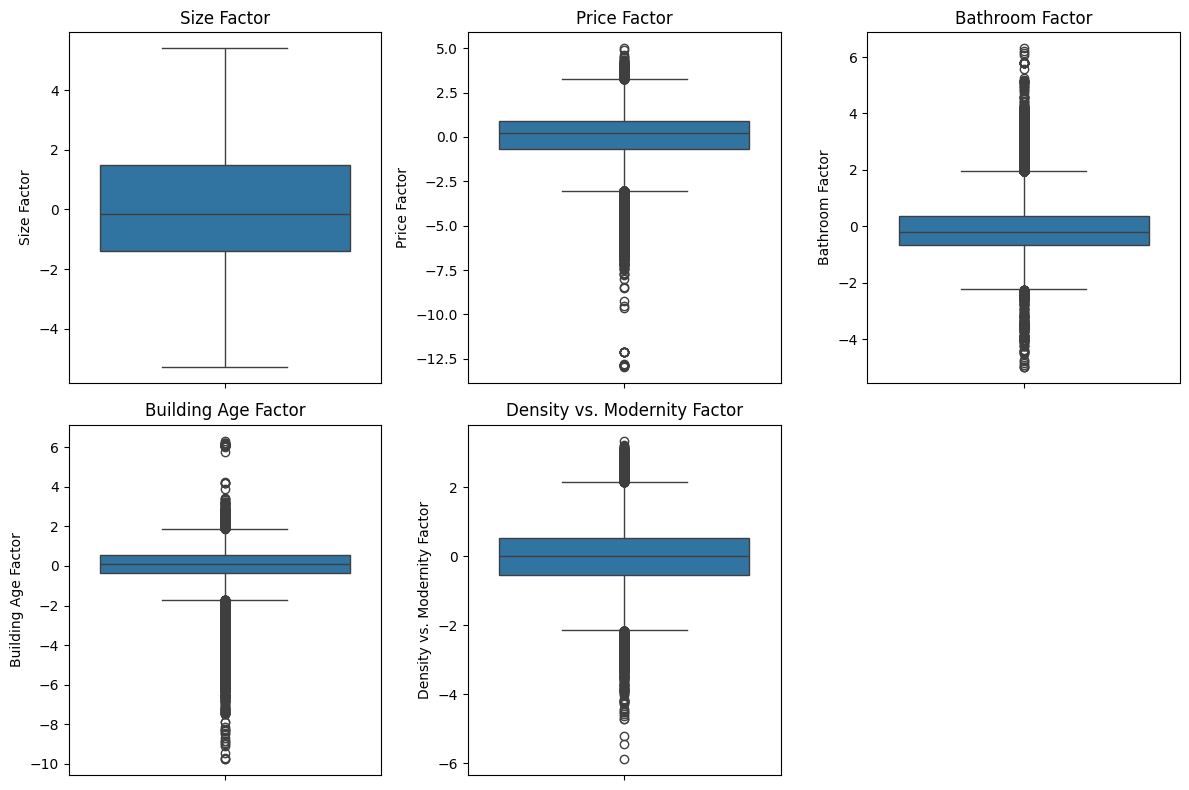

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [ 
    'Size Factor', 
    'Price Factor',
    'Bathroom Factor',
    'Building Age Factor',
    'Density vs. Modernity Factor']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

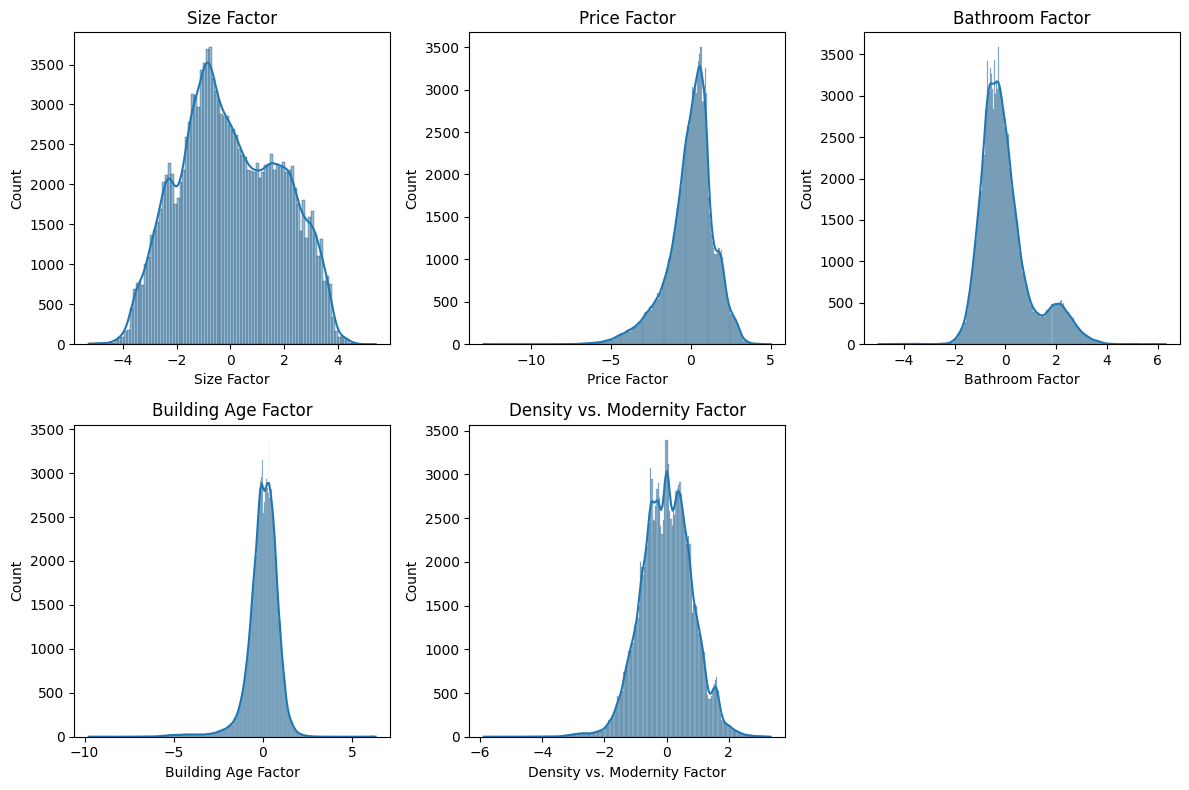

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'Size Factor', 
    'Price Factor',
    'Bathroom Factor',
    'Building Age Factor',
    'Density vs. Modernity Factor'
]

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


In [101]:
from scipy import stats
import numpy as np

zscore_mask = np.zeros(len(df), dtype=bool)
zscore_info = {}

for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    mask = z_scores > 3  
    zscore_info[col] = mask.sum()
    zscore_mask |= mask

df['is_outlier_zscore'] = zscore_mask
print("Z-Score Outliers (|z| > 3):")
print(f"Total: {df['is_outlier_zscore'].sum()} ({df['is_outlier_zscore'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in zscore_info.items():
    print(f"  {col}: {count}")

Z-Score Outliers (|z| > 3):
Total: 5147 (3.55%)

Outliers per PC:
  Size Factor: 0
  Price Factor: 1682
  Bathroom Factor: 1422
  Building Age Factor: 2336
  Density vs. Modernity Factor: 924


In [102]:
outlier_mask = np.zeros(len(df), dtype=bool)
outlier_info = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_info[col] = mask.sum()  
    outlier_mask |= mask

df['is_outlier_iqr'] = outlier_mask
print("IQR Outliers (1.5 * IQR rule):")
print(f"Total: {df['is_outlier_iqr'].sum()} ({df['is_outlier_iqr'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in outlier_info.items():
    print(f"  {col}: {count}")

IQR Outliers (1.5 * IQR rule):
Total: 20897 (14.42%)

Outliers per PC:
  Size Factor: 0
  Price Factor: 6137
  Bathroom Factor: 11322
  Building Age Factor: 5133
  Density vs. Modernity Factor: 1681


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Country                       144961 non-null  object 
 1   Property Type                 144961 non-null  object 
 2   Size Factor                   144961 non-null  float64
 3   Price Factor                  144961 non-null  float64
 4   Bathroom Factor               144961 non-null  float64
 5   Building Age Factor           144961 non-null  float64
 6   Density vs. Modernity Factor  144961 non-null  float64
 7   is_outlier_zscore             144961 non-null  bool   
 8   is_outlier_iqr                144961 non-null  bool   
dtypes: bool(2), float64(5), object(2)
memory usage: 8.0+ MB


In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

COL_TO_TEST = 'Price Factor' 
df_col = df[COL_TO_TEST]

Q1 = df_col.quantile(0.25)
Q3 = df_col.quantile(0.75)
IQR = Q3 - Q1
IQR_LOWER = Q1 - 1.5 * IQR
IQR_UPPER = Q3 + 1.5 * IQR

iqr_outliers_mask = (df_col < IQR_LOWER) | (df_col > IQR_UPPER)
iqr_outlier_count = iqr_outliers_mask.sum()

mean = df_col.mean()
std = df_col.std()
Z_SCORE_LIMIT = 3

Z_LOWER = mean - Z_SCORE_LIMIT * std
Z_UPPER = mean + Z_SCORE_LIMIT * std

zscore_outliers_mask = (df_col < Z_LOWER) | (df_col > Z_UPPER)
zscore_outlier_count = zscore_outliers_mask.sum()

common_outliers_mask = iqr_outliers_mask & zscore_outliers_mask
common_outlier_count = common_outliers_mask.sum()

print(f"--- Comparing found outliers for column: {COL_TO_TEST} ---")
print(f"Total observations: {len(df)}")
print("-" * 50)
print(f"Outliers detected by IQR: {iqr_outlier_count}")
print(f"Outliers detected by Z-score: {zscore_outlier_count}")
print(f"Outliers common to both methods: {common_outlier_count}")

--- Comparing found outliers for column: Price Factor ---
Total observations: 144961
--------------------------------------------------
Outliers detected by IQR: 6137
Outliers detected by Z-score: 1682
Outliers common to both methods: 1682


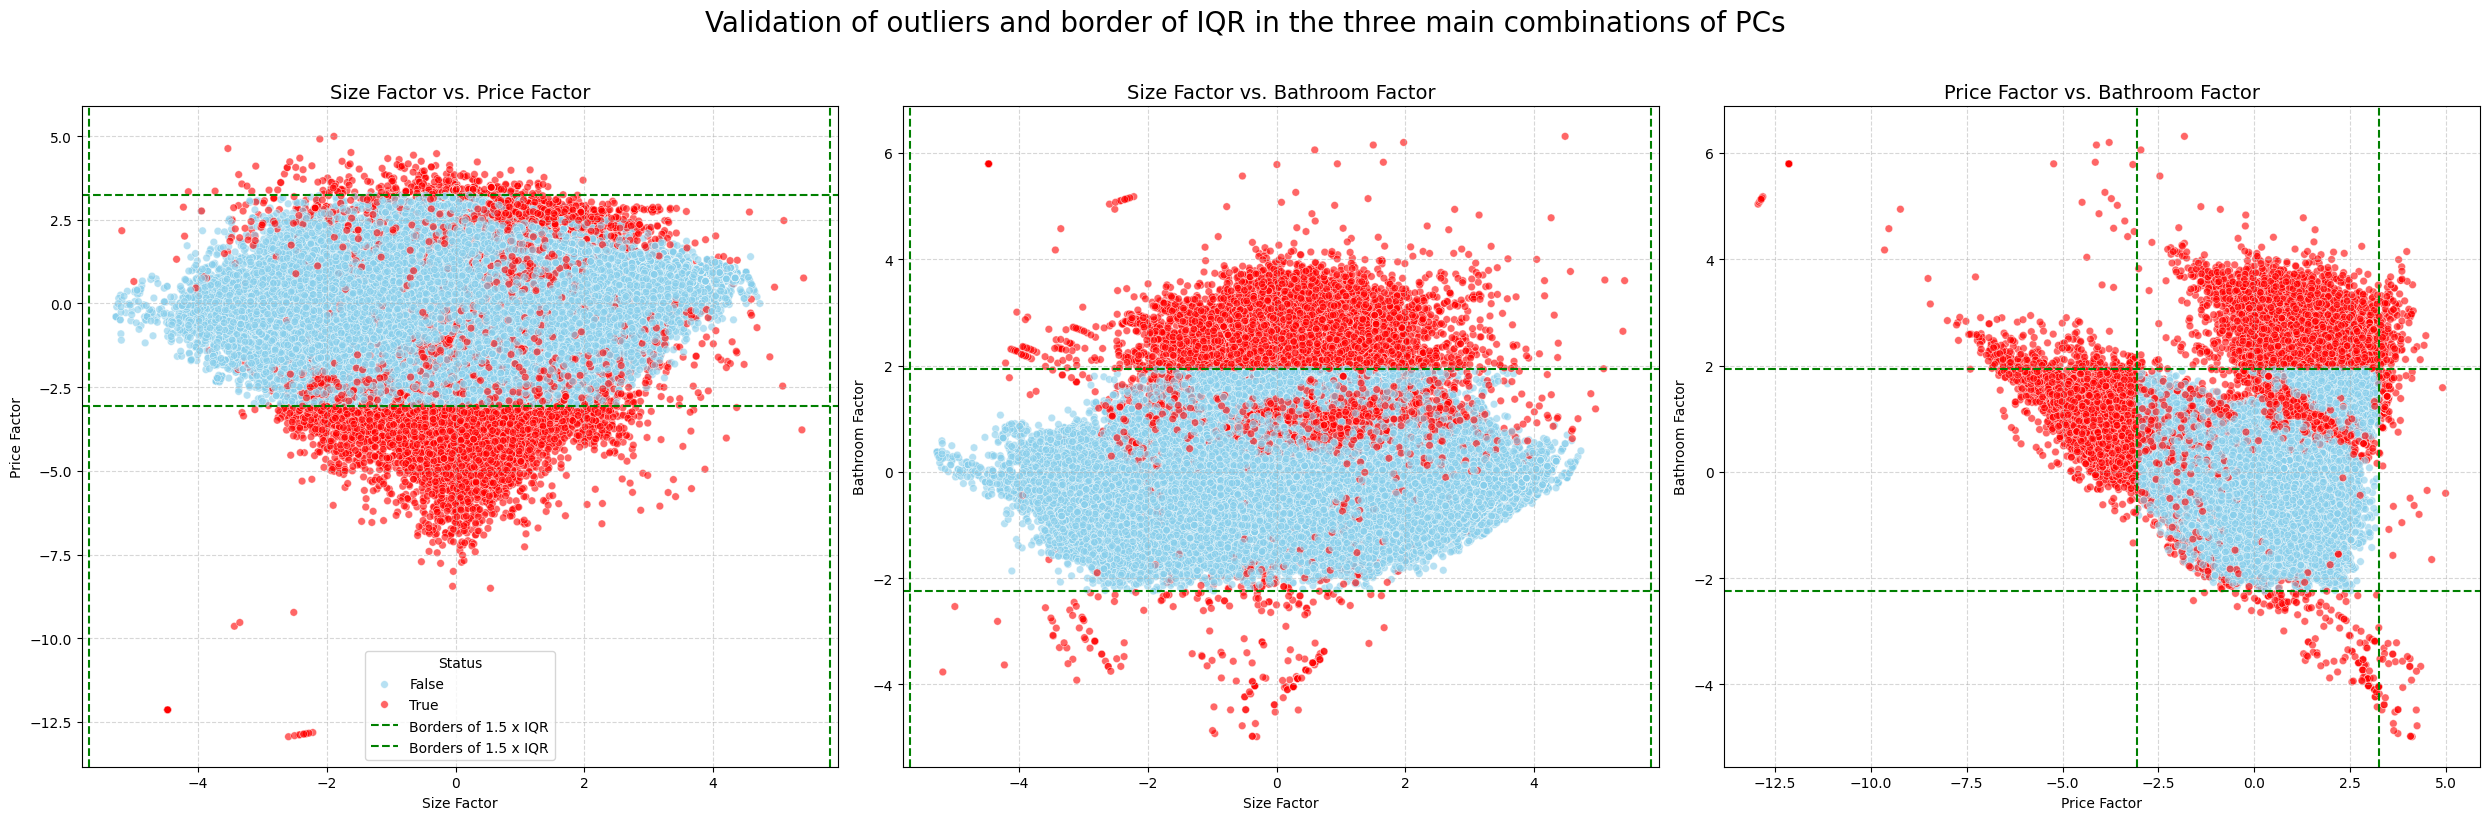

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

pc_pairs = [
    ('Size Factor', 'Price Factor'),
    ('Size Factor', 'Bathroom Factor'),
    ('Price Factor', 'Bathroom Factor')
]

fig, axes = plt.subplots(1, 3, figsize=(25, 8))

plt.suptitle('Validation of outliers and border of IQR in the three main combinations of PCs', fontsize=20, y=1.02)

for i, (pc_x, pc_y) in enumerate(pc_pairs):
    ax = axes[i]
    
    Q1_x, Q3_x = df[pc_x].quantile(0.25), df[pc_x].quantile(0.75)
    IQR_x = Q3_x - Q1_x
    LOWER_x, UPPER_x = Q1_x - 1.5 * IQR_x, Q3_x + 1.5 * IQR_x
    
    Q1_y, Q3_y = df[pc_y].quantile(0.25), df[pc_y].quantile(0.75)
    IQR_y = Q3_y - Q1_y
    LOWER_y, UPPER_y = Q1_y - 1.5 * IQR_y, Q3_y + 1.5 * IQR_y
    
    sns.scatterplot(
        data=df, 
        x=pc_x, 
        y=pc_y, 
        hue='is_outlier_iqr', 
        palette={True: 'red', False: 'skyblue'},
        alpha=0.6, 
        s=30,
        hue_order=[False, True],
        ax=ax
    )
    
    ax.axvline(LOWER_x, color='green', linestyle='--', linewidth=1.5)
    ax.axvline(UPPER_x, color='green', linestyle='--', linewidth=1.5)
    ax.axhline(LOWER_y, color='green', linestyle='--', linewidth=1.5)
    ax.axhline(UPPER_y, color='green', linestyle='--', linewidth=1.5, label='Borders of 1.5 x IQR')
    
    ax.set_title(f'{pc_x} vs. {pc_y}', fontsize=14)
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        handles.append(plt.Line2D([0], [0], color='green', linestyle='--', linewidth=1.5))
        labels.append('Borders of 1.5 x IQR')
        ax.legend(handles, labels, title='Status', loc='best')
    else:
        ax.legend_.remove()

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [106]:
import numpy as np
from scipy.stats import chi2
import pandas as pd

pc_cols = [
    'Size Factor', 
    'Price Factor',
    'Bathroom Factor',
    'Building Age Factor',
    'Density vs. Modernity Factor'
]

X = df[pc_cols].values
N = len(X)
dof = len(pc_cols)

mu = X.mean(axis=0)
Sigma = np.cov(X.T)
try:
    Sigma_inv = np.linalg.inv(Sigma)
except np.linalg.LinAlgError:
    print("Error: Covariance matrix is not invertible. Using pseudo-inverse instead.")
    Sigma_inv = np.linalg.pinv(Sigma)
    Sigma_inv = np.eye(dof)

mahalanobis_distances_squared = []
for i in range(N):
    x_minus_mu = X[i, :] - mu
    dm_squared = x_minus_mu.T @ Sigma_inv @ x_minus_mu
    mahalanobis_distances_squared.append(dm_squared)

df['Mahalanobis_Distance_Squared'] = mahalanobis_distances_squared

alpha = 0.001 
cutoff = chi2.ppf(1 - alpha, dof)

df['is_outlier_mahalanobis'] = df['Mahalanobis_Distance_Squared'] > cutoff

# Rezultatet
mahalanobis_outlier_count = df['is_outlier_mahalanobis'].sum()
mahalanobis_percentage = df['is_outlier_mahalanobis'].mean() * 100

print("\n--- Outlier detection using Mahalanobis distance ---")
print(f"Mahalanobis threshold (Chi-Squared with 5 DOF, p<0.001): {cutoff:.2f}")
print(f"Number of detected outliers: {mahalanobis_outlier_count}")
print(f"Percentage of detected outliers: {mahalanobis_percentage:.2f}%")
print("-" * 50)


--- Outlier detection using Mahalanobis distance ---
Mahalanobis threshold (Chi-Squared with 5 DOF, p<0.001): 20.52
Number of detected outliers: 2358
Percentage of detected outliers: 1.63%
--------------------------------------------------


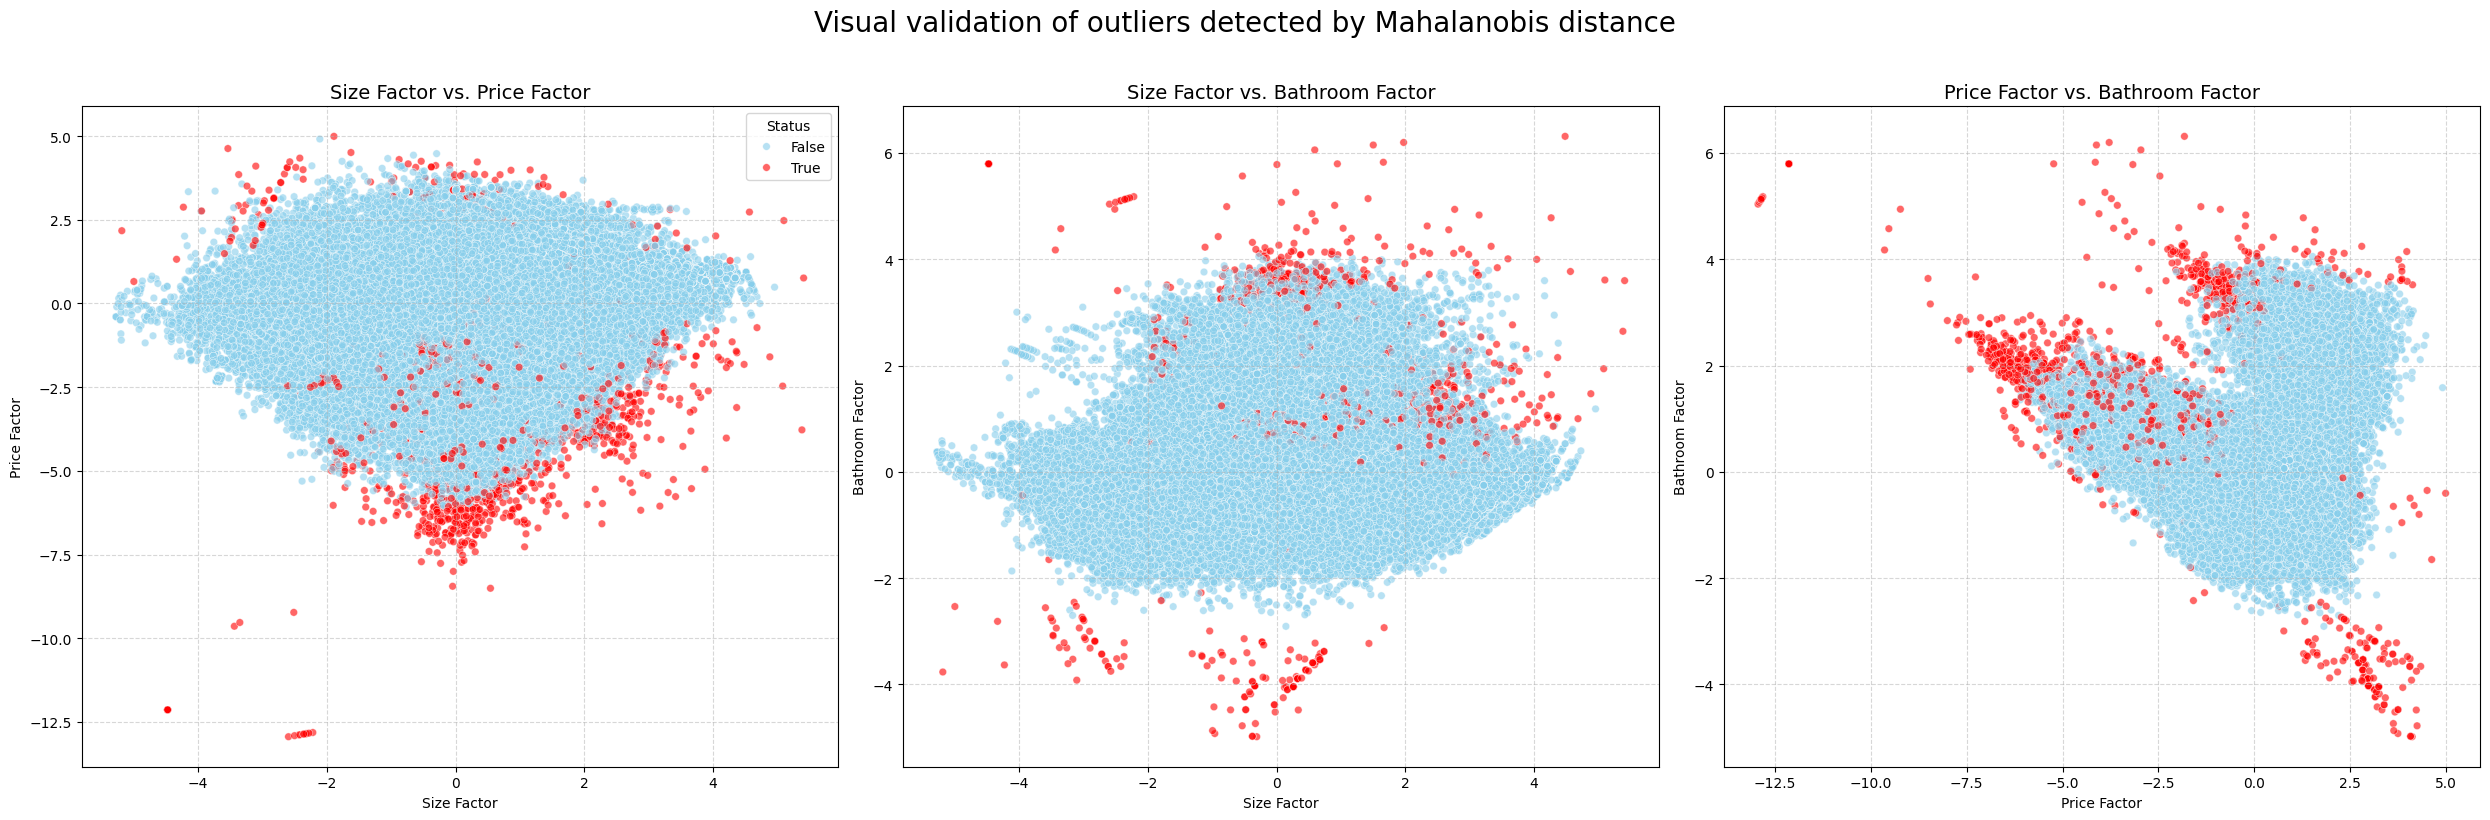

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

pc_pairs = [
    ('Size Factor', 'Price Factor'),
    ('Size Factor', 'Bathroom Factor'),
    ('Price Factor', 'Bathroom Factor')
]

fig, axes = plt.subplots(1, 3, figsize=(25, 8))

plt.suptitle('Visual validation of outliers detected by Mahalanobis distance', fontsize=20, y=1.02)

for i, (pc_x, pc_y) in enumerate(pc_pairs):
    ax = axes[i]
    
    sns.scatterplot(
        data=df, 
        x=pc_x, 
        y=pc_y, 
        hue='is_outlier_mahalanobis', 
        palette={True: 'red', False: 'skyblue'}, 
        alpha=0.6, 
        s=30,
        hue_order=[False, True], 
        ax=ax
    )
    
    ax.set_title(f'{pc_x} vs. {pc_y}', fontsize=14)
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        ax.legend(title='Status')
    else:
        ax.legend_.remove()

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [110]:
df_cleaned = df[~df['is_outlier_mahalanobis']] 

print(f"Original number of rows: {len(df)}")
print(f"Number of rows after outlier removal with Mahalanobis distance: {len(df_cleaned)}")

Original number of rows: 144961
Number of rows after outlier removal with Mahalanobis distance: 142603


In [113]:
from scipy.stats import skew

df_cleaned = df[~df['is_outlier_mahalanobis']].copy() 

X_cleaned = df_cleaned[pc_cols]

print("\n--- Skewness of factors after removing outliers detected by Mahalanobis ---")
for col in X_cleaned.columns:
    s = skew(X_cleaned[col])
    print(f"Skewness for {col}: {s:.4f}")
print("-" * 50)


--- Skewness of factors after removing outliers detected by Mahalanobis ---
Skewness for Size Factor: 0.1115
Skewness for Price Factor: -0.7673
Skewness for Bathroom Factor: 1.1813
Skewness for Building Age Factor: -0.5706
Skewness for Density vs. Modernity Factor: 0.0980
--------------------------------------------------
